> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy


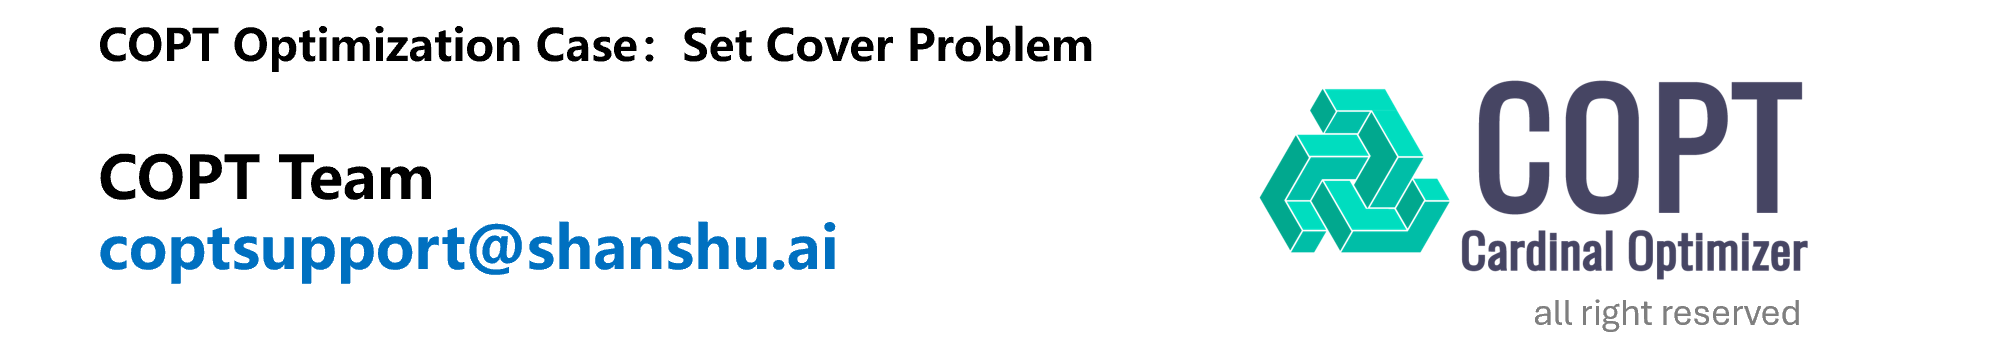

# Set Cover Problem Code Implementation

## Steps to Model and Solve Set Cover Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add Model Data**
    - Import parameter list (including costs of various media channels, covered population categories, etc.)

3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：
        - $x_i$：Binary variable representing whether the $i$ -th media is chosen
    - **Set Objective Function**：Minimize total expense;
    - **Add Constraints**：
        - Each population category must be covered by at least one media channel

5. **Solve**

6. View and interpret the **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

## Add Model Data

In [6]:
# Import media cost information
c = [20000, 50000, 60000, 45000, 30000, 55000, 60000, 52500]
# Import population categories covered by media
cover = [[1, 0, 0, 1, 0, 0],
         [0, 1, 1, 0, 0, 0],
         [0, 1, 0, 0, 0, 1],
         [1, 0, 0, 0, 0, 1],
         [0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 1],
         [0, 1, 0, 0, 1, 0],
         [1, 0, 0, 0, 1, 0]]
# Obtain population information
num_type = len(cover[0])
num_media = len(cover)

## Create the COPT Environment and COPT Model

In [8]:
env = cp.Envr()
model_1 = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
In this case, it is necessary to decide which media combination to select, therefore a binary decision variable is added for each media channel:
$$
    x_i = \begin{cases}
        1, & \text{Media $i$ is chosen}\\
        0, & \text{Media $i$ is not chosen}
    \end{cases}
$$

In [10]:
x = model_1.addVars(num_media, vtype = COPT.BINARY, nameprefix = 'x')

### Set Objective Function
Minimize the total cost of selected media:
$$
    \min \sum_{i} c_i * x_i
$$

In [12]:
model_1.setObjective(cp.quicksum(c[i] * x[i] for i in range(num_media)), sense = COPT.MINIMIZE)

### Add Constraints
Each population category is covered by at least one media channel:
$$
    \sum_{i} cover_{ij} * x_i \geq 1, \forall j = 0, 1, \cdots, num_{type} - 1
$$

In [14]:
model_1.addConstrs(cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) >= 1 for j in range(num_type))

## Solve

In [16]:
model_1.solve()

Model fingerprint: 162a14cf

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    6 rows, 8 columns and 15 non-zero elements
    8 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    5 rows, 7 columns and 13 non-zero elements
    7 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [2e+04,6e+04]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  3.000000e+04            --     Inf  0.04s
H        0         1      --       0  3.00000

## Retrieve Results

In [18]:
media_dict = {
    0: 'Glossy magazine',
    1: 'TV late night',
    2: 'TV prime time',
    3: 'Billboard train',
    4: 'Billboard bus',
    5: 'National paper',
    6: 'Financial paper',
    7: 'Regional paper'
}

if model_1.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_1.objVal} yuan')

    # Index of the chosen media
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print('\nFollowing is the media chosen:')
    for i in selected_media:
        print(f"  - Media {i}: {media_dict[i]}")
    
    # Calculate the coverage frequency of various groups
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\nThe coverage situation of various groups:")
    for j in range(num_type):
        print(f"  - Group {j}: covered {covered[j]} times")

else:
    print('No optimal solution found.')

The optimal cost is 155000.0 yuan

Following is the media chosen:
  - Media 0: Glossy magazine
  - Media 3: Billboard train
  - Media 4: Billboard bus
  - Media 6: Financial paper

The coverage situation of various groups:
  - Group 0: covered 2 times
  - Group 1: covered 1 times
  - Group 2: covered 1 times
  - Group 3: covered 1 times
  - Group 4: covered 1 times
  - Group 5: covered 1 times


# Case Expansion: Set Cover Problem with Various Logical Constraints Code Implementation

1. If Billboard train or Billboard bus are selected, then at least one of TV late night or TV prime time must be selected. This logical relationship corresponds to media index set {3,4} → {1,2}, and its linearized modeling form is as follows:

$$
    x_1 + x_2 \ge x_3
$$

$$
    x_1 + x_2 \ge x_4
$$

In [20]:
# Add constraints
model_1.addConstr(x[1] + x[2] >= x[3])
model_1.addConstr(x[1] + x[2] >= x[4])

# Disable log file display.
model_1.setParam(COPT.Param.Logging, False)

# Solve
model_1.solve()

# Retrieve Results
if model_1.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_1.objVal} yuan')
    variables = model_1.getVars()
    medias = []
    for var in variables:
        if var.x == 1:
            medias.append(int(var.name[2: -1]))
    print('\nFollowing is the media chosen:')
    print(medias)
    covered = [0 for i in range(num_type)]
    for media in medias:
        covered = [covered[i] + cover[media][i] for i in range(num_type)]
    print('Coverage frequency for different population categories is:')
    print(covered)
else:
    print('No optimal solution found.')

The optimal cost is 157500.0 yuan

Following is the media chosen:
[1, 5, 7]
Coverage frequency for different population categories is:
[1, 1, 1, 1, 1, 1]


2. Bidirectional dependency relationship between TV late night and TV prime time, Billboard train and Billboard bus. This constraint characterizes the bidirectional dependency relationship between media set {1,2} (TV late night, TV prime time) and {3,4} (Billboard train, Billboard bus), and its modeling form is:

$$
    x_1 + x_2 \ge x_3
$$

$$
    x_1 + x_2 \ge x_4
$$

$$
    x_3 + x_4 \ge x_1
$$

$$
    x_3 + x_4 \ge x_2
$$

In [22]:
# Add constraints
# model_1.addConstr(x[1] + x[2] >= x[3]) # Added in the last constraint
# model_1.addConstr(x[1] + x[2] >= x[4]) # Added in the last constraint
model_1.addConstr(x[3] + x[4] >= x[1])
model_1.addConstr(x[3] + x[4] >= x[2])

# Solve
model_1.solve()

# Retrieve Results
if model_1.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_1.objVal} yuan')

    # Index of the chosen media
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print('\nFollowing is the media chosen:')
    for i in selected_media:
        print(f"  - Media {i}: {media_dict[i]}")
    
    # Calculate the coverage frequency of various groups
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\nThe coverage situation of various groups:")
    for j in range(num_type):
        print(f"  - Group {j}: covered {covered[j]} times")

else:
    print('No optimal solution found.')

The optimal cost is 162500.0 yuan

Following is the media chosen:
  - Media 0: Glossy magazine
  - Media 2: TV prime time
  - Media 4: Billboard bus
  - Media 7: Regional paper

The coverage situation of various groups:
  - Group 0: covered 2 times
  - Group 1: covered 1 times
  - Group 2: covered 1 times
  - Group 3: covered 1 times
  - Group 4: covered 1 times
  - Group 5: covered 1 times


3. If TV prime time is selected, then both Billboard train and Billboard buss cannot be selected. This exclusivity constraint corresponds to media index relationship 2 → ¬{3,4}, and can be represented as:

$$
    x_3 + x_4 \le 2 \cdot (1 - x_2)
$$

In [24]:
# Add constraints
model_1.addConstr(x[3] + x[4] <= 2 * (1 - x[2]))

# Solve
model_1.solve()

# Retrieve Results
if model_1.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_1.objVal} yuan')

    # Index of the chosen media
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print('\nFollowing is the media chosen:')
    for i in selected_media:
        print(f"  - Media {i}: {media_dict[i]}")
    
    # Calculate the coverage frequency of various groups
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\nThe coverage situation of various groups:")
    for j in range(num_type):
        print(f"  - Group {j}: covered {covered[j]} times")

else:
    print('No optimal solution found.')

The optimal cost is 167500.0 yuan

Following is the media chosen:
  - Media 0: Glossy magazine
  - Media 1: TV late night
  - Media 3: Billboard train
  - Media 7: Regional paper

The coverage situation of various groups:
  - Group 0: covered 3 times
  - Group 1: covered 1 times
  - Group 2: covered 1 times
  - Group 3: covered 1 times
  - Group 4: covered 1 times
  - Group 5: covered 1 times


4. If both Glossy magazine and TV late night are selected, then Financial paper must also be selected. This implication relationship corresponds to media index set {0,1} → 6, and its linearized modeling form is:

$$
    x_6 \ge x_0 + x_1 - 1
$$

In [26]:
# Add constraints
model_1.addConstr(x[6] >= x[0] + x[1] - 1)

# Solve
model_1.solve()

# Retrieve Results
if model_1.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_1.objVal} yuan')

    # Index of the chosen media
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print('\nFollowing is the media chosen:')
    for i in selected_media:
        print(f"  - Media {i}: {media_dict[i]}")
    
    # Calculate the coverage frequency of various groups
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\nThe coverage situation of various groups:")
    for j in range(num_type):
        print(f"  - Group {j}: covered {covered[j]} times")

else:
    print('No optimal solution found.')

The optimal cost is 175000.0 yuan

Following is the media chosen:
  - Media 0: Glossy magazine
  - Media 1: TV late night
  - Media 3: Billboard train
  - Media 6: Financial paper

The coverage situation of various groups:
  - Group 0: covered 2 times
  - Group 1: covered 2 times
  - Group 2: covered 1 times
  - Group 3: covered 1 times
  - Group 4: covered 1 times
  - Group 5: covered 1 times


5. At least three types of target populations are covered by at least two different media. To characterize this coverage intensity constraint, auxiliary binary variable $y_j$ is introduced, and its modeling form is as follows:

$$
    \sum_{j = 0}^{|\mathcal{T}| - 1} y_j \ge 3
$$

$$
    2 \cdot y_j \le \sum_{i = 0}^{|\mathcal{M}| - 1} cover_{ij} \cdot x_i, \quad j = 0, 1, \ldots, |\mathcal{T}| - 1
$$

Where the auxiliary variable $y_j$ is defined as:

$$    y_j = \begin{cases}
        1, & \text{if population type } j \text{ is covered by at least two media} \\
        0, & \text{otherwise}
    \end{cases}
$$

In [28]:
# Add the new variable first
y = model_1.addVars(num_type, vtype=COPT.BINARY, nameprefix='y')

# Add constraint
model_1.addConstr(cp.quicksum(y[j] for j in range(num_type)) >= 3)

<coptpy.Constraint: >

> We use Model.addGenConstrIndicator() to set indicator function constraints. First, it is necessary to rewrite the original constraint:
$$
    y_j = \begin{cases}
        1, & \sum_i cover_{ij} \cdot x_i >= 2 \\
        0, & \sum_i cover_{ij} \cdot x_i < 2 \\
    \end{cases}
    , \forall j = 0, 1, \cdots, num_{type} - 1 \\
$$

In [30]:
for j in range(num_type):
    model_1.addGenConstrIndicator(y[j], True, cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) >= 2, type=COPT.INDICATOR_IFANDONLYIF)

<font color=#B9C78D>
<b>Tip: COPT Indicator Function</b>
</font>   

Here, we adopt a constraint addition method in COPT, namely the indicator function. Its essence is to introduce an auxiliary binary variable to represent whether certain logical conditions hold or not, thereby transforming complex logical constraints into linear or manageable mathematical forms. This method is actually an implementation of the Big-M method, which introduces a sufficiently large constant M to transform originally nonlinear constraint conditions into linear constraints with explicit inequality forms, facilitating solver processing and optimization.

In [32]:
# Solve
model_1.solve()

# Retrieve Results
if model_1.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_1.objVal} yuan')

    # Index of the chosen media
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print('\nFollowing is the media chosen:')
    for i in selected_media:
        print(f"  - Media {i}: {media_dict[i]}")
    
    # Calculate the coverage frequency of various groups
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\nThe coverage situation of various groups:")
    for j in range(num_type):
        print(f"  - Group {j}: covered {covered[j]} times")

else:
    print('No optimal solution found.')

The optimal cost is 205000.0 yuan

Following is the media chosen:
  - Media 0: Glossy magazine
  - Media 1: TV late night
  - Media 3: Billboard train
  - Media 4: Billboard bus
  - Media 6: Financial paper

The coverage situation of various groups:
  - Group 0: covered 2 times
  - Group 1: covered 2 times
  - Group 2: covered 2 times
  - Group 3: covered 1 times
  - Group 4: covered 1 times
  - Group 5: covered 1 times


From the solution results, it can be observed that as constraints are gradually added, the optimal objective function value of the model shows an overall increasing trend. This is because new constraints restrict some originally feasible and lower-cost solutions, forcing the model to optimize within a smaller feasible solution space, thereby requiring the selection of higher-cost media combinations.

## Case Expansion: Variants of the Set Cover Problem Code Implementation
### Set Partition problem
The set partition problem can be regarded as a special form of the set cover problem, with the main difference lying in stricter requirements for coverage frequency. In the set cover problem, each target element only needs to be covered by at least one subset; whereas in the set partition problem, it is further required that each element is covered exactly once by one subset.

Therefore, its coverage constraint is adjusted from "not less than once" to "exactly once", and the corresponding constraint condition is:

$$
    \sum_{i \in \mathcal{M}} cover_{ij} \cdot x_i = 1,
    \quad j = 0, 1, \ldots, |\mathcal{T}| - 1
$$


In [35]:
# Create COPT model
model_2 = env.createModel()

# Add three core components of COPT Model\
# Add Decision Variables
x = model_2.addVars(num_media, vtype = COPT.BINARY, nameprefix = 'x')

# Set Objective Function
model_2.setObjective(cp.quicksum(c[i] * x[i] for i in range(num_media)), sense = COPT.MINIMIZE)

# Add Constraints. Notice that changes happen here
model_2.addConstrs(cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) == 1 for j in range(num_type))

# Disable log file display.
model_2.setParam(COPT.Param.Logging, False)

# Solve
model_2.solve()

# Retrieve Results
if model_2.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_2.objVal} yuan')

    # Index of the chosen media
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print('\nFollowing is the media chosen:')
    for i in selected_media:
        print(f"  - Media {i}: {media_dict[i]}")
    
    # Calculate the coverage frequency of various groups
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\nThe coverage situation of various groups:")
    for j in range(num_type):
        print(f"  - Group {j}: covered {covered[j]} times")

else:
    print('No optimal solution found.')

The optimal cost is 157500.0 yuan

Following is the media chosen:
  - Media 1: TV late night
  - Media 5: National paper
  - Media 7: Regional paper

The coverage situation of various groups:
  - Group 0: covered 1 times
  - Group 1: covered 1 times
  - Group 2: covered 1 times
  - Group 3: covered 1 times
  - Group 4: covered 1 times
  - Group 5: covered 1 times


### Set Packing Problem
Compared to the set partition problem, the set packing problem exhibits more significant differences in modeling form from the original set cover problem. This problem no longer focuses on "whether all elements are covered" but emphasizes selecting as many valuable subsets as possible from multiple candidate sets without conflicts. In this model, the objective function transforms from minimizing total costs to maximizing the sum of weights of selected subsets; simultaneously, the coverage constraint is adjusted from "covering at least once" to "covering at most once" to avoid the same element being repeatedly selected by multiple subsets.

Its mathematical model can be expressed as:

$$
\begin{aligned}
    \max \quad 
    & \sum_{i \in \mathcal{M}} c_i \cdot x_i \\
    \text{s.t.} \quad 
    & \sum_{i \in \mathcal{M}} cover_{ij} \cdot x_i \le 1,
    \quad j = 0, 1, \ldots, |\mathcal{T}| - 1, \\
    & x_i \in \{0, 1\},
    \quad i = 0, 1, \ldots, |\mathcal{M}| - 1.
\end{aligned}
$$

In [37]:
# Create COPT model
model_3 = env.createModel()

# Add three core components of COPT Model

# Add Decision Variables
x = model_3.addVars(num_media, vtype = COPT.BINARY, nameprefix = 'x')

# Set Objective Function
model_3.setObjective(cp.quicksum(c[i] * x[i] for i in range(num_media)), sense = COPT.MAXIMIZE)

# Add Constraints. Notice that changes happen here
model_3.addConstrs(cp.quicksum(cover[i][j] * x[i] for i in range(num_media)) <= 1 for j in range(num_type))

# Disable log file display.
model_3.setParam(COPT.Param.Logging, False)

# Solve
model_3.solve()

# Retrieve Results
if model_3.status == COPT.OPTIMAL:
    print(f'The optimal cost is {model_3.objVal} yuan')

    # Index of the chosen media
    selected_media = [i for i in range(num_media) if x[i].x > 0.5]

    print('\nFollowing is the media chosen:')
    for i in selected_media:
        print(f"  - Media {i}: {media_dict[i]}")
    
    # Calculate the coverage frequency of various groups
    covered = [0] * num_type
    for i in selected_media:
        for j in range(num_type):
            covered[j] += cover[i][j]

    print("\nThe coverage situation of various groups:")
    for j in range(num_type):
        print(f"  - Group {j}: covered {covered[j]} times")

else:
    print('No optimal solution found.')

The optimal cost is 157500.0 yuan

Following is the media chosen:
  - Media 1: TV late night
  - Media 5: National paper
  - Media 7: Regional paper

The coverage situation of various groups:
  - Group 0: covered 1 times
  - Group 1: covered 1 times
  - Group 2: covered 1 times
  - Group 3: covered 1 times
  - Group 4: covered 1 times
  - Group 5: covered 1 times
